In [32]:
import os
import random
import numpy as np
import keras
from keras import ops
from keras import layers
from keras import optimizers
from keras import metrics
from keras import Model
import tensorflow as tf
from PIL import Image
from keras.applications.resnet_v2 import preprocess_input
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Dataset Path**

In [33]:
LFW_DIR = "LFW/"
IMAGE_DIR = os.path.join(LFW_DIR, "lfw-deepfunneled")
PAIRS_FILE = os.path.join(LFW_DIR, "pairs.csv")

**Load LFW dataset and Create triplet**

In [34]:
def generate_triplet_sets_from_LFW_Data(data_folder, link_file, resize_to):
    """
    Constructs triplet data (base, similar, dissimilar) by reading metadata
    and loading image contents into memory.
    """
    base_set, similar_set, dissimilar_set = [], [], []

    # Gather all images for use in negative sampling
    img_library = []
    for root, _, files in os.walk(data_folder):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                img_library.append(os.path.join(root, f))

    # Parse relationship CSV
    valid_matches = []
    with open(link_file, 'r') as fh:
        next(fh)  # Ignore column labels
        for entry in fh:
            components = entry.strip().split(',')
            if len(components) == 3 or (len(components) == 4 and components[3] == ''):
                name = components[0]
                id1 = int(components[1])
                id2 = int(components[2])
                src1 = os.path.join(data_folder, name, f"{name}_{id1:04d}.jpg")
                src2 = os.path.join(data_folder, name, f"{name}_{id2:04d}.jpg")
                valid_matches.append((src1, src2, name))

    print(f"Collected {len(valid_matches)} confirmed pairs. Building structured samples...")

    for base_img_path, similar_img_path, identity_tag in valid_matches:
        try:
            # Select a mismatched image (from different person)
            imposter_path = random.choice(img_library)
            while identity_tag in imposter_path:
                imposter_path = random.choice(img_library)

            # Load and preprocess all 3 images
            img_a = np.array(Image.open(base_img_path).convert("RGB").resize(resize_to), dtype="float32")
            img_b = np.array(Image.open(similar_img_path).convert("RGB").resize(resize_to), dtype="float32")
            img_c = np.array(Image.open(imposter_path).convert("RGB").resize(resize_to), dtype="float32")

            base_set.append(img_a)
            similar_set.append(img_b)
            dissimilar_set.append(img_c)
        except FileNotFoundError:
            print(f"Notice: Could not locate file(s) for identity {identity_tag}. Skipped.")
            continue

    print("All data entries successfully compiled.")
    return np.array(base_set), np.array(similar_set), np.array(dissimilar_set)


# --- Load and organize dataset into memory ---
trip_a, trip_b, trip_c = generate_triplet_sets_from_LFW_Data(IMAGE_DIR, PAIRS_FILE, (128,128))

# Random shuffle
shuffler = np.random.permutation(len(trip_a))
trip_a, trip_b, trip_c = trip_a[shuffler], trip_b[shuffler], trip_c[shuffler]

# Partition into training and validation sets
split_point = int(0.8 * len(trip_a))
a_train, b_train, c_train = trip_a[:split_point], trip_b[:split_point], trip_c[:split_point]
a_val, b_val, c_val = trip_a[split_point:], trip_b[split_point:], trip_c[split_point:]

print(f"\nTotal structured triplets: {len(trip_a)}")
print("---")
print(f"Training samples:    {len(a_train)}")
print(f"Validation samples:  {len(a_val)}")
print("---")
print(f"Input shape (train A): {a_train.shape}")


Collected 3000 confirmed pairs. Building structured samples...
All data entries successfully compiled.

Total structured triplets: 3000
---
Training samples:    2400
Validation samples:  600
---
Input shape (train A): (2400, 128, 128, 3)


**Preprocess the dataset**

In [35]:
# Apply ResNetV2 preprocessing
anchors_train = preprocess_input(a_train)
positives_train = preprocess_input(b_train)
negatives_train = preprocess_input(c_train)

anchors_val = preprocess_input(a_val)
positives_val = preprocess_input(b_val)
negatives_val = preprocess_input(c_val)

**Define the model**

In [36]:
def create_embedding_network(input_shape):
    # Define the ResNet50V2 base model
    base_cnn = keras.applications.ResNet50V2(
        weights="imagenet", 
        input_shape=input_shape,
        include_top=False,
    )

    # Set layers to be trainable as requested
    trainable = False
    for layer in base_cnn.layers:
        if layer.name == "conv5_block1_out":
            trainable = True
        layer.trainable = trainable

    # Add a custom head for embedding generation
    flatten = keras.layers.Flatten()(base_cnn.output)
    x = keras.layers.Dense(512, activation="relu")(flatten)
    x = keras.layers.BatchNormalization()(x)
    output = keras.layers.Dense(256)(x) # 256-dimensional embedding

    return keras.Model(base_cnn.input, output, name="Embedding")

# Define the input shape for our LFW images
input_shape = (128,128,3)
embedding_network = create_embedding_network(input_shape)

anchor_input = layers.Input(name="anchor", shape=input_shape)
positive_input = layers.Input(name="positive", shape=input_shape)
negative_input = layers.Input(name="negative", shape=input_shape)

# Generate the embeddings for the anchor, positive, and negative images
# by reusing the same embedding network instance.
embedded_anchor = embedding_network(anchor_input)
embedded_positive = embedding_network(positive_input)
embedded_negative = embedding_network(negative_input)

# The siamese network is a model that takes 3 images and returns 3 embeddings
siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input],
    outputs=[embedded_anchor, embedded_positive, embedded_negative]
)

**Build SiameseModel Class**

In [37]:
class SiameseModel(Model):
    def __init__(self, net_core, gap=0.5):
        super().__init__()
        self.siamese_network = net_core
        self.margin = gap
        self.loss_meter = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, batch):
        # Unwrap the triplet (anchor, pos, neg)
        triplet_set = batch[0]

        with tf.GradientTape() as g:
            total_loss = self._triplet_loss(triplet_set)

        grads = g.gradient(total_loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.siamese_network.trainable_weights))
        self.loss_meter.update_state(total_loss)
        return {"loss": self.loss_meter.result()}

    def test_step(self, batch):
        sample = batch[0]
        eval_loss = self._triplet_loss(sample)
        self.loss_meter.update_state(eval_loss)
        return {"loss": self.loss_meter.result()}

    def _triplet_loss(self, batch_inputs):
        base_img, similar_img, different_img = batch_inputs

        embed_a, embed_b, embed_c = self.siamese_network([base_img, similar_img, different_img])

        # Calculate squared L2 distances
        pos_dist = ops.sum(ops.square(embed_a - embed_b), axis=-1)
        neg_dist = ops.sum(ops.square(embed_a - embed_c), axis=-1)

        basic_loss = pos_dist - neg_dist + self.margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))

    @property
    def metrics(self):
        return [self.loss_meter]


**Train the model**

In [38]:
siamese_model = SiameseModel(siamese_network,)
siamese_model.compile(optimizer=optimizers.Adam(0.0001))

history = siamese_model.fit(
    x=(anchors_train, positives_train, negatives_train),
    y=None,
    validation_data=((anchors_val, positives_val, negatives_val), None),
    batch_size=16,
    epochs=30,
)

Epoch 1/30


150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 29.0864 - val_loss: 1.3862
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.3882 - val_loss: 1.2574
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0416 - val_loss: 1.3206
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0163 - val_loss: 1.3108
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0047 - val_loss: 1.3507
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0069 - val_loss: 1.3734
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0094 - val_loss: 1.4185
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0095 - val_loss: 1.3952
Epoch 9/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0285 - val_loss: 1.2760
Epoch 10/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0364 - val_loss: 1.4700
Epoch 11/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0584 - val_loss: 1.6761
Epoch 12/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/s

**Visualize the Loss**

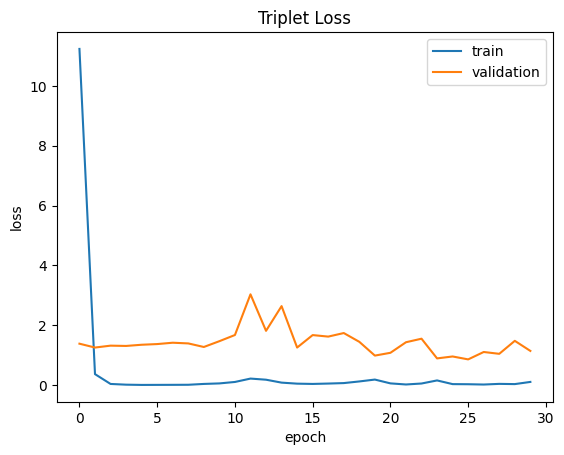

In [39]:
def plt_metric(history, metric, title):
    plt.plot(history.history[metric])
    plt.plot(history.history["val_" + metric])
    plt.legend(["train", "validation"], loc="upper right")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()

plt_metric(history=history, metric="loss", title="Triplet Loss")

**Visualize Sample of Triplets**

In [41]:
def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""
    def show(ax, image):
        # De-normalize from ResNet's [-1, 1] to the original [0, 255] for display
        image = ((image + 1) * 127.5).astype(np.uint8)
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))
    fig.suptitle("Anchor | Positive | Negative", fontsize=16)
    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])
    plt.show()

Showing a sample of triplets from the validation set:



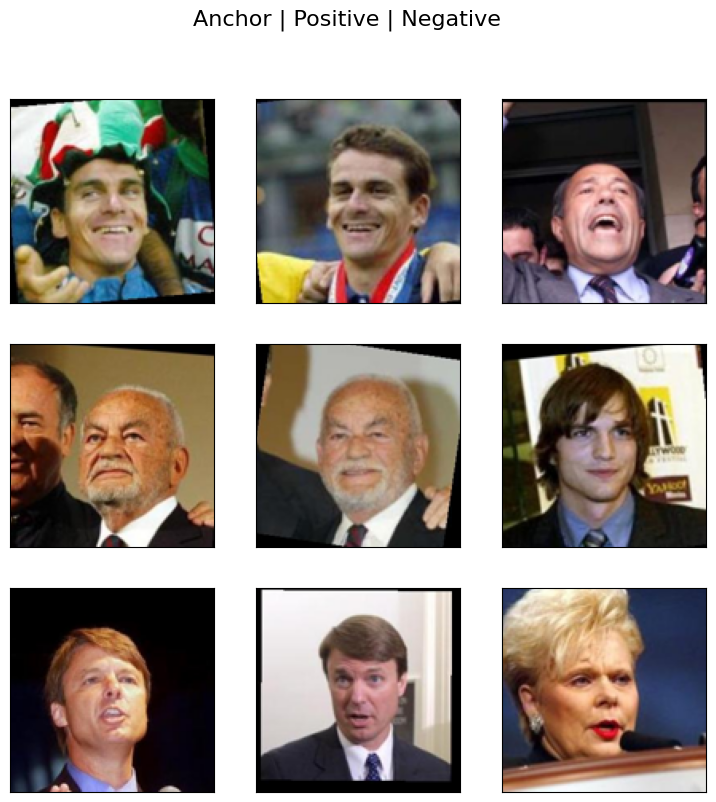

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

--- Calculated Distances for the Triplets Above ---

Triplet 1:
  Anchor-Positive Distance: 1.7462
  Anchor-Negative Distance: 4.7455
  Result: Correctly separated!

Triplet 2:
  Anchor-Positive Distance: 0.6843
  Anchor-Negative Distance: 2.6140
  Result: Correctly separated!

Triplet 3:
  Anchor-Positive Distance: 6.6088
  Anchor-Negative Distance: 6.8278
  Result: Correctly separated!


In [45]:
num_samples = 3
sample_anchors = anchors_val[:num_samples]
sample_positives = positives_val[:num_samples]
sample_negatives = negatives_val[:num_samples]

print("Showing a sample of triplets from the validation set:\n")
# We use your existing visualize function with the un-preprocessed images
visualize(sample_anchors, sample_positives, sample_negatives)


# --- Step 2: Preprocess the sample images for prediction ---
anchors_preprocessed = preprocess_input(sample_anchors.astype("float32"))
positives_preprocessed = preprocess_input(sample_positives.astype("float32"))
negatives_preprocessed = preprocess_input(sample_negatives.astype("float32"))


# --- Step 3: Generate embeddings for the sample ---
# We use the standalone embedding_network for this
anchor_embedding = embedding_network.predict(anchors_preprocessed)
positive_embedding = embedding_network.predict(positives_preprocessed)
negative_embedding = embedding_network.predict(negatives_preprocessed)


# --- Step 4: Calculate distances and print the results ---
print("\n--- Calculated Distances for the Triplets Above ---")
for i in range(num_samples):
    # Calculate the squared Euclidean distances (as used in the loss function)
    ap_distance = np.sum(np.square(anchor_embedding[i] - positive_embedding[i]))
    an_distance = np.sum(np.square(anchor_embedding[i] - negative_embedding[i]))
    
    print(f"\nTriplet {i+1}:")
    print(f"  Anchor-Positive Distance: {ap_distance:.4f}")
    print(f"  Anchor-Negative Distance: {an_distance:.4f}")
    if ap_distance < an_distance:
        print("  Result: Correctly separated!")
    else:
        print("  Result: Incorrectly separated.")

In [46]:
batch_size = 16
sample_anchors = anchors_val[:batch_size]
sample_positives = positives_val[:batch_size]
sample_negatives = negatives_val[:batch_size]

# Generate embeddings for the sample triplets using the siamese_network.
# The network was defined to output a list of three tensors: 
# [anchor_embeddings, positive_embeddings, negative_embeddings]
anchor_embedding, positive_embedding, negative_embedding = siamese_network.predict(
    [sample_anchors, sample_positives, sample_negatives]
)

# Instantiate the CosineSimilarity metric
cosine_similarity = metrics.CosineSimilarity()

# Calculate the similarity between the anchor and the positive embeddings
positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())

# Calculate the similarity between the anchor and the negative embeddings
negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity:", negative_similarity.numpy())

# For a more concise view, we can also print the average similarity
print("\nAverage positive similarity:", np.mean(positive_similarity.numpy()))
print("Average negative similarity:", np.mean(negative_similarity.numpy()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Positive similarity: 0.65916383
Negative similarity: 0.5875021

Average positive similarity: 0.65916383
Average negative similarity: 0.5875021
